In [3]:
!curl -L -o face-mask-dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/omkargurav/face-mask-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  163M  100  163M    0     0  84.4M      0  0:00:01  0:00:01 --:--:--  106M


In [ ]:
!unzip -qq face-mask-dataset.zip

In [5]:
import os
import copy
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, accuracy_score
import cv2

import numpy as np
from torchvision import transforms, datasets
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from PIL import Image

CPU = torch.device("cpu")  # quantization + real edge benchmarking must be measured on CPU


def get_model_size_mb(model, tmp_path="_tmp_model_size.pth"):
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return size_mb


@torch.no_grad()
def evaluate_model(model, loader, device=CPU, class_names=None):
    model.eval()
    model.to(device)
    all_labels, all_preds = [], []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec}


@torch.no_grad()
def measure_latency(model, input_size=(1, 3, 224, 224), device=CPU, n_warmup=10, n_runs=100):
    model.eval()
    model.to(device)
    dummy = torch.randn(*input_size).to(device)

    for _ in range(n_warmup):
        model(dummy)

    start = time.perf_counter()
    for _ in range(n_runs):
        model(dummy)
    end = time.perf_counter()

    avg_ms = (end - start) / n_runs * 1000
    return avg_ms


def benchmark(name, model, loader, results, device=CPU):
    metrics = evaluate_model(model, loader, device=device)
    size_mb = get_model_size_mb(model)
    latency_ms = measure_latency(model, device=device)

    results[name] = {**metrics, "size_mb": size_mb, "latency_ms": latency_ms}
    print(f"[{name}]")
    print(f"  Precision: {metrics['precision']:.4f}  Recall: {metrics['recall']:.4f}  Acc: {metrics['accuracy']:.4f}")
    print(f"  Size: {size_mb:.2f} MB   CPU latency: {latency_ms:.2f} ms/image")
    print("-" * 60)
    return results


results = {}

In [7]:
device = CPU
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_root = "/content/data"
full_dataset = datasets.ImageFolder(root=dataset_root, transform=transform_pipeline)


from torch.utils.data import random_split, DataLoader
# calculate lengths for an 80% train and 20% test split
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# perform the random split
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# create loaders (used by benchmark/evaluation later)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# load the saved file; it may be a state_dict (OrderedDict) or a full model
loaded = torch.load("./mobilenet_mask_classifier.pth", map_location=device)

if isinstance(loaded, dict):
    # instantiate MobileNetV2 architecture and load the state_dict
    from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

    num_classes = len(full_dataset.classes)
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    model.load_state_dict(loaded)
    baseline_model = model.to(CPU)
else:
    # loaded is already a model
    baseline_model = copy.deepcopy(loaded)
    baseline_model = baseline_model.to(CPU)

results = benchmark("Baseline (FP32)", baseline_model, test_loader, results, device=CPU)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Baseline (FP32)]
  Precision: 0.9955  Recall: 0.9953  Acc: 0.9954
  Size: 8.72 MB   CPU latency: 30.69 ms/image
------------------------------------------------------------


1. QUANTIZATION — TYPE 1: Dynamic Quantization

Dynamic quantization converts *weights* of specified layer types to int8 ahead of
time; activations are quantized on-the-fly at inference. It requires no calibration
data and is a one-line change, but it only touches nn.Linear (and LSTM/RNN) layers —
it does NOT touch nn.Conv2d. Since MobileNetV2 is ~98% convolutions, dynamic
quantization here mainly shrinks/speeds up the classifier head, not the backbone.

In [8]:

dynamic_quant_model = torch.quantization.quantize_dynamic(
    copy.deepcopy(baseline_model),
    {nn.Linear},
    dtype=torch.qint8,
)

results = benchmark("Dynamic Quantization (INT8 Linear)", dynamic_quant_model, test_loader, results, device=CPU)

/tmp/ipykernel_1247/1446266012.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  dynamic_quant_model = torch.quantization.quantize_dynamic(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Dynamic Quantization (INT8 Linear)]
  Precision: 0.9955  Recall: 0.9953  Acc: 0.9954
  Size: 8.72 MB   CPU latency: 25.71 ms/image
------------------------------------------------------------



2. QUANTIZATION — TYPE 2: Static Post-Training Quantization (PTQ)

Static quantization quantizes BOTH weights and activations of Conv2d + Linear layers,
so it actually compresses the MobileNetV2 backbone (where nearly all the compute is).
It needs a short calibration pass over representative data to learn activation ranges.

We use torchvision's `quantization.mobilenet_v2`, which is architecturally identical
to the standard mobilenet_v2 but has QuantStub/DeQuantStub inserted and a fuse_model()
helper that fuses Conv+BN(+ReLU6) into single ops — required for good quantized
accuracy. Because the underlying layers are unchanged, we can load your trained
weights straight into it.

In [9]:

from torchvision.models.quantization import mobilenet_v2 as quantizable_mobilenet_v2


def build_quantizable_mask_classifier(num_classes=2):
    model = quantizable_mobilenet_v2(weights=None, quantize=False)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(model.last_channel, num_classes),
    )
    return model


quant_ready_model = build_quantizable_mask_classifier(num_classes=len(full_dataset.classes))
quant_ready_model.load_state_dict(baseline_model.state_dict())
quant_ready_model.eval()
quant_ready_model.fuse_model()

# pick a quantized backend that's actually supported on this platform
if "onednn" in torch.backends.quantized.supported_engines:
    EDGE_BACKEND = "onednn"
elif "qnnpack" in torch.backends.quantized.supported_engines:
    EDGE_BACKEND = "qnnpack"
else:
    raise RuntimeError(
        f"No supported quantized backend available. Supported engines: {torch.backends.quantized.supported_engines}"
    )

torch.backends.quantized.engine = EDGE_BACKEND
print("Using quantized backend:", torch.backends.quantized.engine)

# ensure model is on CPU for calibration/quantization
quant_ready_model.to(CPU)
quant_ready_model.qconfig = torch.quantization.get_default_qconfig(EDGE_BACKEND)

torch.quantization.prepare(quant_ready_model, inplace=True)

with torch.no_grad():
    for i, (images, _) in enumerate(train_loader):
        quant_ready_model(images.to(CPU))
        if i >= 20:
            break

static_quant_model = torch.quantization.convert(quant_ready_model, inplace=False)

results = benchmark("Static PTQ (INT8 Conv+Linear)", static_quant_model, test_loader, results, device=CPU)

Using quantized backend: onednn


/tmp/ipykernel_1247/4220879228.py:33: UserWarning: Default qconfig of oneDNN backend with reduce_range of false may have accuracy issues on CPU without Vector Neural Network Instruction support.
  quant_ready_model.qconfig = torch.quantization.get_default_qconfig(EDGE_BACKEND)
/tmp/ipykernel_1247/4220879228.py:35: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.quant

[Static PTQ (INT8 Conv+Linear)]
  Precision: 0.9909  Recall: 0.9906  Acc: 0.9907
  Size: 2.53 MB   CPU latency: 20.42 ms/image
------------------------------------------------------------



3. PRUNING — Global unstructured L1 pruning + fine-tune recovery

We zero out the smallest-magnitude 40% of weights across all Conv2d/Linear layers
(global, so layers that matter more naturally keep more of their weights), then
fine-tune for a couple of epochs to recover any lost accuracy, then make the pruning
permanent (bake the zero mask into the actual weight tensor).

IMPORTANT CAVEAT (worth stating in your report): unstructured pruning like this
reduces the *logical* parameter count and compresses well with sparse formats, but a
plain dense CPU inference won't get faster just from zeros in a dense tensor — you
need either a sparsity-aware runtime (e.g. NCNN/TFLite sparse kernels) or structured
pruning (removing whole channels/filters) to see real latency wins on typical edge
runtimes. We prune globally here for accuracy/size demonstration and call out
structured pruning as the recommended follow-up for latency-critical deployment.

In [ ]:
import torch.nn.utils.prune as prune

prune_model = copy.deepcopy(baseline_model).to("cuda")  # fine-tune on original training device (GPU if available)

parameters_to_prune = [
    (module, "weight")
    for module in prune_model.modules()
    if isinstance(module, (nn.Conv2d, nn.Linear))
]

PRUNE_AMOUNT = 0.4  # 40% of weights (by magnitude) zeroed globally
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=PRUNE_AMOUNT,
)

total_params, zero_params = 0, 0
for module, _ in parameters_to_prune:
    total_params += module.weight.nelement()
    zero_params += torch.sum(module.weight == 0).item()
print(f"Global sparsity after pruning: {100 * zero_params / total_params:.2f}%")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(prune_model.parameters(), lr=1e-4)

FT_EPOCHS = 2
for epoch in range(FT_EPOCHS):
    prune_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to("cuda"), labels.to("cuda")
        optimizer.zero_grad()
        outputs = prune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"[Prune fine-tune] Epoch {epoch+1}/{FT_EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

for module, _ in parameters_to_prune:
    prune.remove(module, "weight")

pruned_model = prune_model.to(CPU)
results = benchmark("Pruned (40% global, fine-tuned)", pruned_model, test_loader, results, device=CPU)

Global sparsity after pruning: 40.00%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Prune fine-tune] Epoch 1/2 - Loss: 0.0082


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Prune fine-tune] Epoch 2/2 - Loss: 0.0020


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Pruned (40% global, fine-tuned)]
  Precision: 0.9987  Recall: 0.9987  Acc: 0.9987
  Size: 8.72 MB   CPU latency: 24.43 ms/image
------------------------------------------------------------


4. KNOWLEDGE DISTILLATION — MobileNetV3-Small student trained on teacher's soft labels

Teacher = your fine-tuned MobileNetV2 (frozen, eval mode).
Student = MobileNetV3-Small (roughly 3-4x fewer params/FLOPs than V2), trained from
ImageNet weights but re-fitted to the mask task using a distillation loss that mixes:
(a) standard cross-entropy against the true labels, and
(b) KL-divergence between softened teacher and student output distributions
(temperature T softens the distribution so the student also learns *how
confident/uncertain* the teacher was between the two classes, not just the label).

In [14]:

from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights


def get_student_model(num_classes=2):
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model.to("cuda")


teacher_model = copy.deepcopy(baseline_model).to("cuda")
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

student_model = get_student_model(num_classes=len(full_dataset.classes))

TEMPERATURE = 4.0
ALPHA = 0.5


def distillation_loss(student_logits, teacher_logits, labels, T=TEMPERATURE, alpha=ALPHA):
    hard_loss = F.cross_entropy(student_logits, labels)
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction="batchmean",
    ) * (T * T)
    return alpha * hard_loss + (1 - alpha) * soft_loss


optimizer = optim.Adam(student_model.parameters(), lr=1e-3)
DISTILL_EPOCHS = 5

for epoch in range(DISTILL_EPOCHS):
    student_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to("cuda"), labels.to("cuda")

        with torch.no_grad():
            teacher_logits = teacher_model(images)

        optimizer.zero_grad()
        student_logits = student_model(images)
        loss = distillation_loss(student_logits, teacher_logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"[Distillation] Epoch {epoch+1}/{DISTILL_EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

distilled_student_model = student_model.to(CPU)
results = benchmark("Distilled Student (MobileNetV3-Small)", distilled_student_model, test_loader, results, device=CPU)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Distillation] Epoch 1/5 - Loss: 0.3563


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Distillation] Epoch 2/5 - Loss: 0.1020


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

[Distillation] Epoch 4/5 - Loss: 0.0606


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Distillation] Epoch 5/5 - Loss: 0.0555


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[Distilled Student (MobileNetV3-Small)]
  Precision: 0.9934  Recall: 0.9934  Acc: 0.9934
  Size: 5.92 MB   CPU latency: 9.27 ms/image
------------------------------------------------------------


6. FINAL COMPARISON

                                       precision  recall  accuracy  size_mb  \
Baseline (FP32)                            0.995   0.995     0.995    8.725   
Dynamic Quantization (INT8 Linear)         0.995   0.995     0.995    8.718   
Static PTQ (INT8 Conv+Linear)              0.991   0.991     0.991    2.527   
Pruned (40% global, fine-tuned)            0.999   0.999     0.999    8.725   
Distilled Student (MobileNetV3-Small)      0.993   0.993     0.993    5.924   

                                       latency_ms  speedup_vs_baseline  \
Baseline (FP32)                            30.688                1.000   
Dynamic Quantization (INT8 Linear)         25.710                1.194   
Static PTQ (INT8 Conv+Linear)              20.423                1.503   
Pruned (40% global, fine-tuned)            24.427                1.256   
Distilled Student (MobileNetV3-Small)       9.272                3.310   

                                       size_reduction_vs_baseline  
Baseline (FP

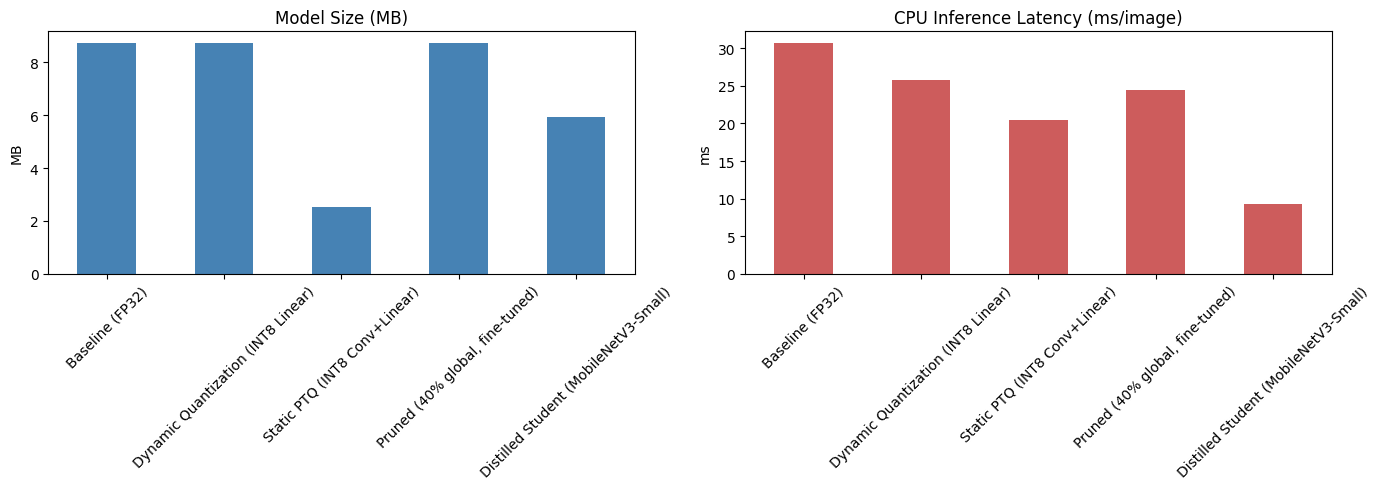

In [15]:
import pandas as pd

comparison_df = pd.DataFrame(results).T
comparison_df["speedup_vs_baseline"] = (
    comparison_df.loc["Baseline (FP32)", "latency_ms"] / comparison_df["latency_ms"]
)
comparison_df["size_reduction_vs_baseline"] = (
    1 - comparison_df["size_mb"] / comparison_df.loc["Baseline (FP32)", "size_mb"]
) * 100

pd.set_option("display.float_format", "{:.3f}".format)
print(comparison_df[["precision", "recall", "accuracy", "size_mb", "latency_ms",
                      "speedup_vs_baseline", "size_reduction_vs_baseline"]])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
comparison_df["size_mb"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Model Size (MB)")
axes[0].set_ylabel("MB")
axes[0].tick_params(axis="x", rotation=45)

comparison_df["latency_ms"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("CPU Inference Latency (ms/image)")
axes[1].set_ylabel("ms")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()